# Cell-Cell Communication Analysis

This notebook was inspired by the "steady-state ligand-receptor inference" tutorial using the liana package: https://liana-py.readthedocs.io/en/latest/notebooks/basic_usage.html

`liana` provides different statistical methods to infer `ligand-receptor` interactions from single-cell transcriptomics data omics data using prior knowledge.
In this notebook we showcase how to use liana with mesothelial tissue data.

We also refer users to the [Cell-cell communication chapter](https://www.sc-best-practices.org/mechanisms/cell_cell_communication.html) in the [best-practices guide from Theis lab](https://www.nature.com/articles/s41576-023-00586-w). There we provide an overview of the common limitations and assumptions in CCC inference from (dissociated single-cell) transcriptomics data.

## Loading Packages

In [1]:
import custom_functions_scviEnv as cf
import liana as li
import matplotlib.pyplot as plt
import scanpy as sc

plt.rcParams['font.family'] = 'Arial'

/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/numba/np/ufunc/parallel.py:373: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.


In [2]:
li.__version__

'1.7.1'

## Loading data

In the most general case, `liana`'s ligand-receptor methods use `anndata` objects with processed single-cell transcriptomics data, with pre-defined cell labels (identities), to infer ligand-receptor interactions among all pairs of cell identities.

In [ ]:
adata = sc.read_h5ad('../data/adata_meso_tapvat_combined_preprocessed.h5ad')

In [ ]:
### For reloading after liana results have been added to the adata object
# adata.write_h5ad('../data/meso_tapvat_adata_with_liana_results.h5ad')

In [5]:
adata.obs['tissue_type'] = adata.obs['tissue_type'].astype('str')
adata.obs['celltype_broad'] = adata.obs['celltype_broad'].astype('str')
adata.obs['celltype'] = adata.obs['celltype'].astype('str')

In [6]:
adata.obs["tissue_celltype_broad"] = adata.obs["tissue_type"] + "_" + adata.obs["celltype_broad"]
adata.obs["tissue_celltype"] = adata.obs["tissue_type"] + "_" + adata.obs["celltype"]

## Background

`liana` typically works with the log1p-trasformed counts matrix, in this object the normalized counts are stored in `raw`:

In [6]:
adata.raw.X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 23561594 stored elements and shape (21933, 21298)>

Preferably, one would use `liana` with all features (genes) for which we have enough counts, which we do here.

In the background, `liana` aggregates the counts matrix and generates statistics, typically related to cell identies.
These statistics are then utilized by each of the methods in `liana`.

### Methods

In [25]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


Each method infers relevant ligand-receptor interactions relying on different assumptions and each method returns different ligand-receptor scores, typically a pair per method. One score corresponding to
the `magnitude` (strength) of interaction and the other reflecting how `specificity` of a given interaction to a pair cell identities.

## By default, LIANA+ uses **human gene symbols**. See the documentation and the [Prior Knowledge vignette](https://liana-py.readthedocs.io/en/latest/notebooks/prior_knowledge.html) for details and instructions for homology conversion.


## Convert Human gene symbols to Mouse

Liana used their "consensus" database as the default. They also have a "mouseconsensus" database. If you want to use another resource's database on non-human data, you will have to convert the gene names:

In [8]:
resource = li.rs.select_resource('cellchatdb')
resource

,ligand,receptor
7395,JAG2,NOTCH1
7396,DLL1,NOTCH1
7397,IGF1,IGF1R
7398,JAG1,NOTCH1
7399,WNT5A,FZD2
...,...,...
9302,LAMB2,ITGA1_ITGB1
9303,LAMB3,ITGA1_ITGB1
9304,LAMC1,ITGA1_ITGB1
9305,LAMC2,ITGA1_ITGB1


In [9]:
map_df = li.rs.get_hcop_orthologs(filename = '../data/human_mouse_hcop_fifteen_column.txt.gz',
                                  columns=['human_symbol', 'mouse_symbol'],
                                   # NOTE: HCOP integrates multiple resource, so we can filter out mappings in at least 3 of them for confidence
                                   min_evidence=3
                                   )
# rename the columns to source and target, respectively for the original organism and the target organism
map_df = map_df.rename(columns={'human_symbol':'source', 'mouse_symbol':'target'})



/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/resource/_orthology.py:204: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


In [10]:
# We will then translate
resource_mouse = li.rs.translate_resource(resource,
                                 map_df=map_df,
                                 columns=['ligand', 'receptor'],
                                 replace=True,
                                 # Here, we will be harsher and only keep mappings that don't map to more than 1 mouse gene
                                 one_to_many=1
                                 )
resource_mouse

,ligand,receptor
7395,Jag2,Notch1
7396,Dll1,Notch1
7397,Igf1,Igf1r
7398,Jag1,Notch1
7399,Wnt5a,Fzd2
...,...,...
9302,Lamb2,Itga1_Itgb1
9303,Lamb3,Itga1_Itgb1
9304,Lamc1,Itga1_Itgb1
9305,Lamc2,Itga1_Itgb1


### Individual Methods

In [11]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [34]:
# run cellchat on cellchatdb
cellchat(adata,
            groupby='tissue_celltype_broad', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource=resource_mouse, # NOTE: default is 'consensus'
            expr_prop=0.1,
            verbose=True, key_added='ccdb_res')

Using `.raw`!


/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Converting `tissue_celltype_broad` to categorical!
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
['Cyp2c6_v1-ps2', 'Metazoa_SRP-12', 'Metazoa_SRP-13', 'Metazoa_SRP-16', 'Metazoa_SRP-17', 'Metazoa_SRP-22', 'Metazoa_SRP-24', 'RNaseP_nuc-23', 'RNase_MRP', 'Y_RNA-10', 'Y_RNA-5'] contain `_`. Consider replacing those!


Using provided `resource`.


0.13 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 21933 samples and 656 features


/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/_pipe_utils/_get_mean_perms.py:43: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
100%|██████████| 1000/1000 [03:30<00:00,  4.75it/s]


<div class="alert alert-info">

**Note**

LIANA will by default use the `.raw` attribute of AnnData. If you wish to use .X set `use_raw` to `False`, or specify a `layer`.

LIANA will also by default use the 'consensus' resource to infer ligand-receptor interactions. 
This resource was created as a consensus from the resources literature-curated resources in OmniPath, and uses **human gene symbols**.

For different species, we provide 'mouseconsensus', for any other species you can provide your own resource, or translate LIANA's resources as shown [here](https://liana-py.readthedocs.io/en/latest/notebooks/prior_knowledge.html#Homology-Mapping).

If you wish to use a different resource, please specify it via the `resource_name` parameter for internal resources, or provide an external one via `resource` or `interactions`.
    
</div>  

In [60]:
# run cellchat on mouseconsensus
cellchat(adata,
            groupby='tissue_celltype_broad', 
            resource_name='mouseconsensus',
            expr_prop=0.1,
            verbose=True, key_added='mcdb_res')

Using resource `mouseconsensus`.
Using `.raw`!
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Converting `tissue_celltype_broad` to categorical!
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
['Cyp2c6_v1-ps2', 'Metazoa_SRP-12', 'Metazoa_SRP-13', 'Metazoa_SRP-16', 'Metazoa_SRP-17', 'Metazoa_SRP-22', 'Metazoa_SRP-24', 'RNaseP_nuc-23', 'RNase_MRP', 'Y_RNA-10', 'Y_RNA-5'] contain `_`. Consider replacing those!
0.13 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 21933 samples and 1346 features


/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/anndata/_core/anndata.py:630: FutureWarning: Setting element `.X` of view of `AnnData` object will obey copy-on-write semantics in the next minor release. 
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/_pipe_utils/_get_mean_perms.py:43: ImplicitModificationWarning: Modifying `X` on a view results in data being overridden
100%|██████████| 1000/1000 [07:30<00:00,  2.22it/s]


By default, liana will be run **inplace** and results will be assigned to `adata.uns['liana_res']`.
Note that the high proportion of missing entities here is expected, as we are working on the reduced dimensions data.

In [35]:
# cellchatdb output is saved in place:
adata.uns['ccdb_res'].head()

,ligand,ligand_complex,ligand_props,ligand_trimean,mat_max,receptor,receptor_complex,receptor_props,receptor_trimean,source,target,lr_probs,cellchat_pvals
1238,Vegfa,Vegfa,0.984218,0.324328,8.708414,Flt1,Flt1,0.875982,0.344195,Adipose_Adipocytes_Brown,Adipose_Endothelial_Cells,0.182515,0.0
1607,Sema3c,Sema3c,0.920000,0.363828,8.708414,Plxna2,Nrp1_Plxna2,0.775940,0.263451,Adipose_Mesothelial_Cells,Adipose_Endothelial_Cells,0.160864,0.0
1299,Vegfa,Vegfa,0.903188,0.275545,8.708414,Flt1,Flt1,0.875982,0.344195,Adipose_Adipocytes_White,Adipose_Endothelial_Cells,0.159440,0.0
5988,Lama2,Lama2,0.968182,0.433276,8.708414,Sv2c,Sv2c,0.736842,0.208579,Adipose_Fibroblasts,Adipose_Schwann_Cells,0.153077,0.0
277,Sema3c,Sema3c,0.920000,0.363828,8.708414,Plxna2,Nrp1_Plxna2,0.833308,0.213845,Adipose_Mesothelial_Cells,Adipose_Adipocytes_Brown,0.134653,0.0


In [38]:
adata.uns['ccdb_res'][adata.uns['ccdb_res']['source'] == 'Mesothelium_Mesothelial_Cells']

,ligand,ligand_complex,ligand_props,ligand_trimean,mat_max,receptor,receptor_complex,receptor_props,receptor_trimean,source,target,lr_probs,cellchat_pvals
2015,Sema3c,Sema3c,0.373222,0.096294,8.708414,Plxna2,Nrp1_Plxna2,0.775940,0.263451,Mesothelium_Mesothelial_Cells,Adipose_Endothelial_Cells,0.048287,0.0
591,Sema3c,Sema3c,0.373222,0.096294,8.708414,Plxna2,Nrp1_Plxna2,0.833308,0.213845,Mesothelium_Mesothelial_Cells,Adipose_Adipocytes_Brown,0.039555,0.0
594,Sema3c,Sema3c,0.373222,0.096294,8.708414,Nrp2,Nrp2_Plxna2,0.615963,0.111635,Mesothelium_Mesothelial_Cells,Adipose_Adipocytes_Brown,0.021047,0.0
2018,Sema3c,Sema3c,0.373222,0.096294,8.708414,Nrp2,Nrp2_Plxna2,0.389004,0.060769,Mesothelium_Mesothelial_Cells,Adipose_Endothelial_Cells,0.011568,0.0
2011,Sema3c,Sema3c,0.373222,0.096294,8.708414,Plxnd1,Plxnd1,0.450599,0.057623,Mesothelium_Mesothelial_Cells,Adipose_Endothelial_Cells,0.010976,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2861,Col1a2,Col1a2,0.174397,0.000000,8.708414,Itga11,Itga11_Itgb1,0.246970,0.000000,Mesothelium_Mesothelial_Cells,Adipose_Fibroblasts,0.000000,1.0
2859,Col1a1,Col1a1,0.127087,0.000000,8.708414,Itga11,Itga11_Itgb1,0.246970,0.000000,Mesothelium_Mesothelial_Cells,Adipose_Fibroblasts,0.000000,1.0
2858,Gas6,Gas6,0.179035,0.000000,8.708414,Axl,Axl,0.336364,0.048097,Mesothelium_Mesothelial_Cells,Adipose_Fibroblasts,0.000000,1.0
2857,Fgf1,Fgf1,0.115337,0.000000,8.708414,Fgfr1,Fgfr1,0.460606,0.057450,Mesothelium_Mesothelial_Cells,Adipose_Fibroblasts,0.000000,1.0


In [61]:
# mouseconsensus output is saved in place:
adata.uns['mcdb_res'].head()

,ligand,ligand_complex,ligand_props,ligand_trimean,mat_max,receptor,receptor_complex,receptor_props,receptor_trimean,source,target,lr_probs,cellchat_pvals
12533,Ncam1,Ncam1,0.842105,0.307416,8.708414,Cacna1c,Cacna1c,0.972973,0.422512,Adipose_Schwann_Cells,Adipose_Pericytes_SMCs,0.206207,0.0
3376,Vegfa,Vegfa,0.984218,0.324328,8.708414,Nrp1,Nrp1,0.837536,0.339754,Adipose_Adipocytes_Brown,Adipose_Endothelial_Cells,0.180586,0.0
4248,C4a,C4a,0.928000,0.317408,8.708414,Nrp1,Nrp1,0.837536,0.339754,Adipose_Mesothelial_Cells,Adipose_Endothelial_Cells,0.177416,0.0
4184,Sema3c,Sema3c,0.920000,0.363828,8.708414,Plxna2,Nrp1_Plxna2,0.775940,0.263451,Adipose_Mesothelial_Cells,Adipose_Endothelial_Cells,0.160864,0.0
3527,Vegfa,Vegfa,0.903188,0.275545,8.708414,Nrp1,Nrp1,0.837536,0.339754,Adipose_Adipocytes_White,Adipose_Endothelial_Cells,0.157707,0.0


Here, we see that stats are provided for both ligand and receptor entities, more specifically: `ligand` and `receptor` are the two entities that potentially interact. As a reminder, CCC events are not limited to secreted signalling, but we refer to them as `ligand` and `receptor` for simplicity.

Also, in the case of heteromeric complexes, the `ligand` and `receptor` columns represent the subunit with minimum expression, while `*_complex` corresponds to the actual complex, with subunits being separated by `_`.

- `source` and `target` columns represent the source/sender and target/receiver cell identity for each interaction, respectively

- `*_props`: represents the proportion of cells that express the entity. 

  By default, any interactions in which either entity is not expressed in above 10% of cells per cell type is considered as a false positive,
  under the assumption that since CCC occurs between cell types, a sufficient proportion of cells within should express the genes.

- `*_means`: entity expression mean per cell type

- `lr_means`: mean ligand-receptor expression, as a measure of ligand-receptor interaction **magnitude**

- `cellphone_pvals`: permutation-based p-values, as a measure of interaction **specificity**

<div class="alert alert-info">

**Note**
    
`ligand`, `receptor`, `source`, and `target` columns are returned by every ligand-receptor method, while the rest of the columns can vary across the ligand-receptor methods, as each method infers relies on different assumptions and scoring functions, and hence each returns different ligand-receptor scores. Nevertheless, typically most methods use a pair of scoring functions - where one often corresponds to the **magnitude** (strength) of interaction and the other reflects how **specificity** of a given interaction to a pair cell identities.
    
</div>

### Dotplot

We can now visualize the results that we just obtained.

LIANA provides some basic, but flexible plotting functionalities. Here, we will generate a dotplot of relevant ligand-receptor interactions.

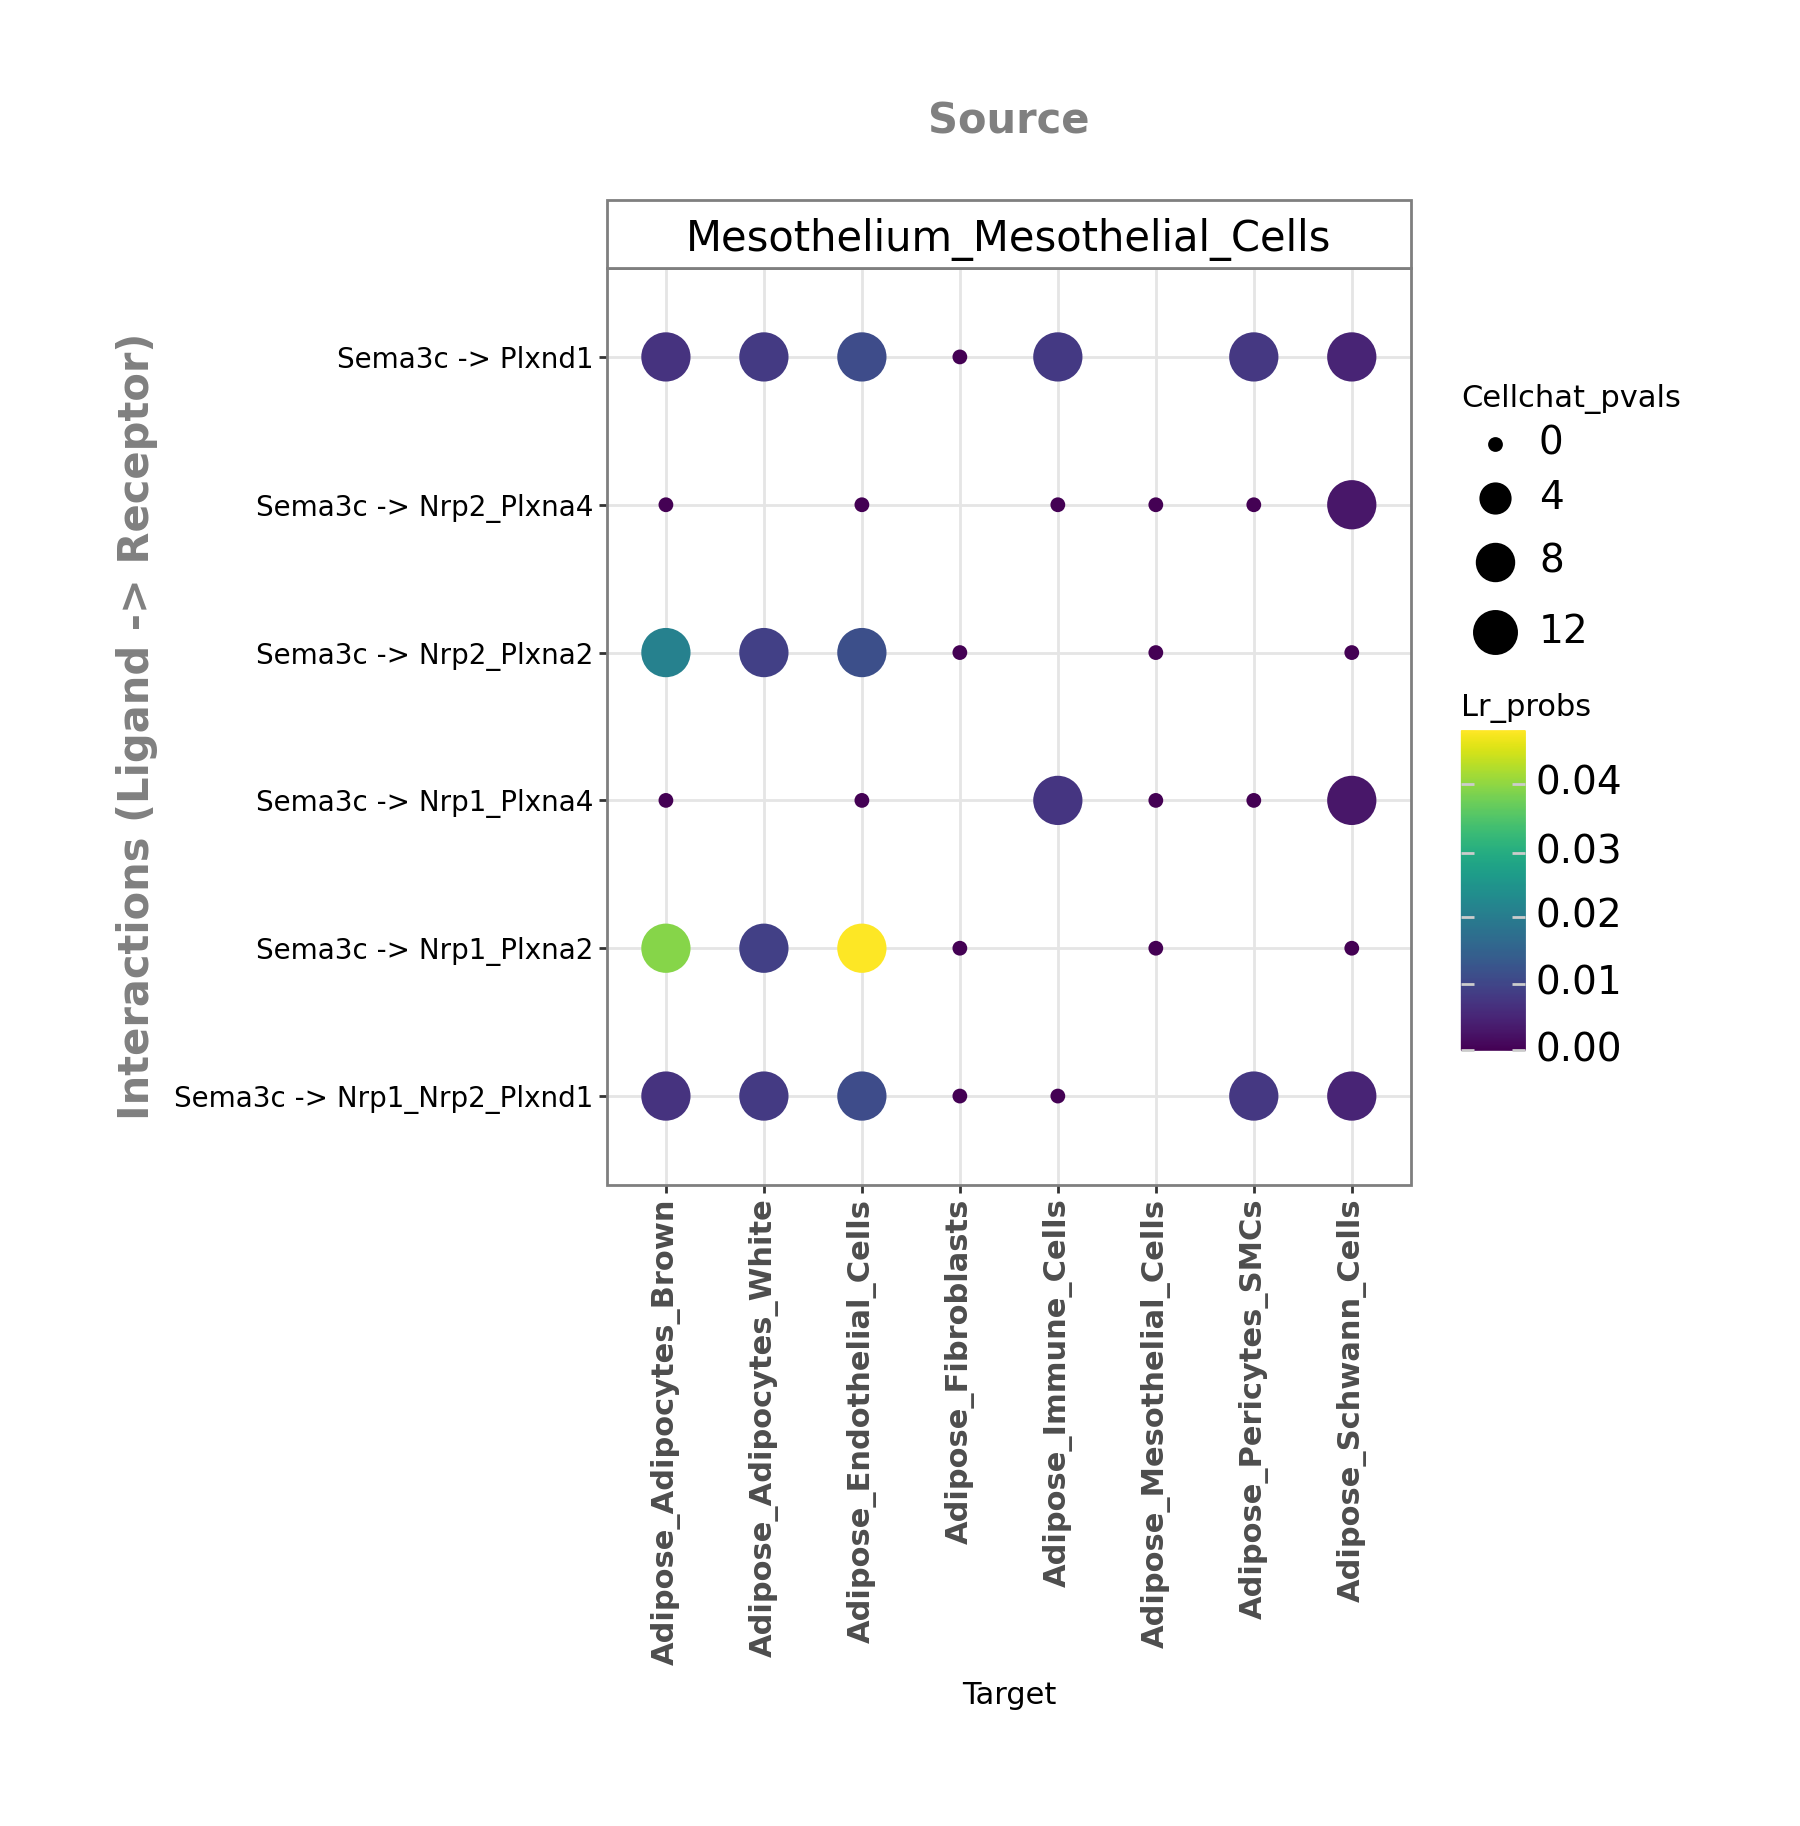

In [137]:
li.pl.dotplot(adata = adata, 
              colour='lr_probs',
              size='cellchat_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              source_labels='Mesothelium_Mesothelial_Cells',
              target_labels=list(adata[adata.obs.tissue_type == 'Adipose'].obs['tissue_celltype_broad'].unique()),
              figure_size=(8, 8),
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              filter_fun=lambda x: x['cellchat_pvals'] <= 0.5,
              uns_key='ccdb_res' # uns_key to use, default is 'liana_res' 
             )

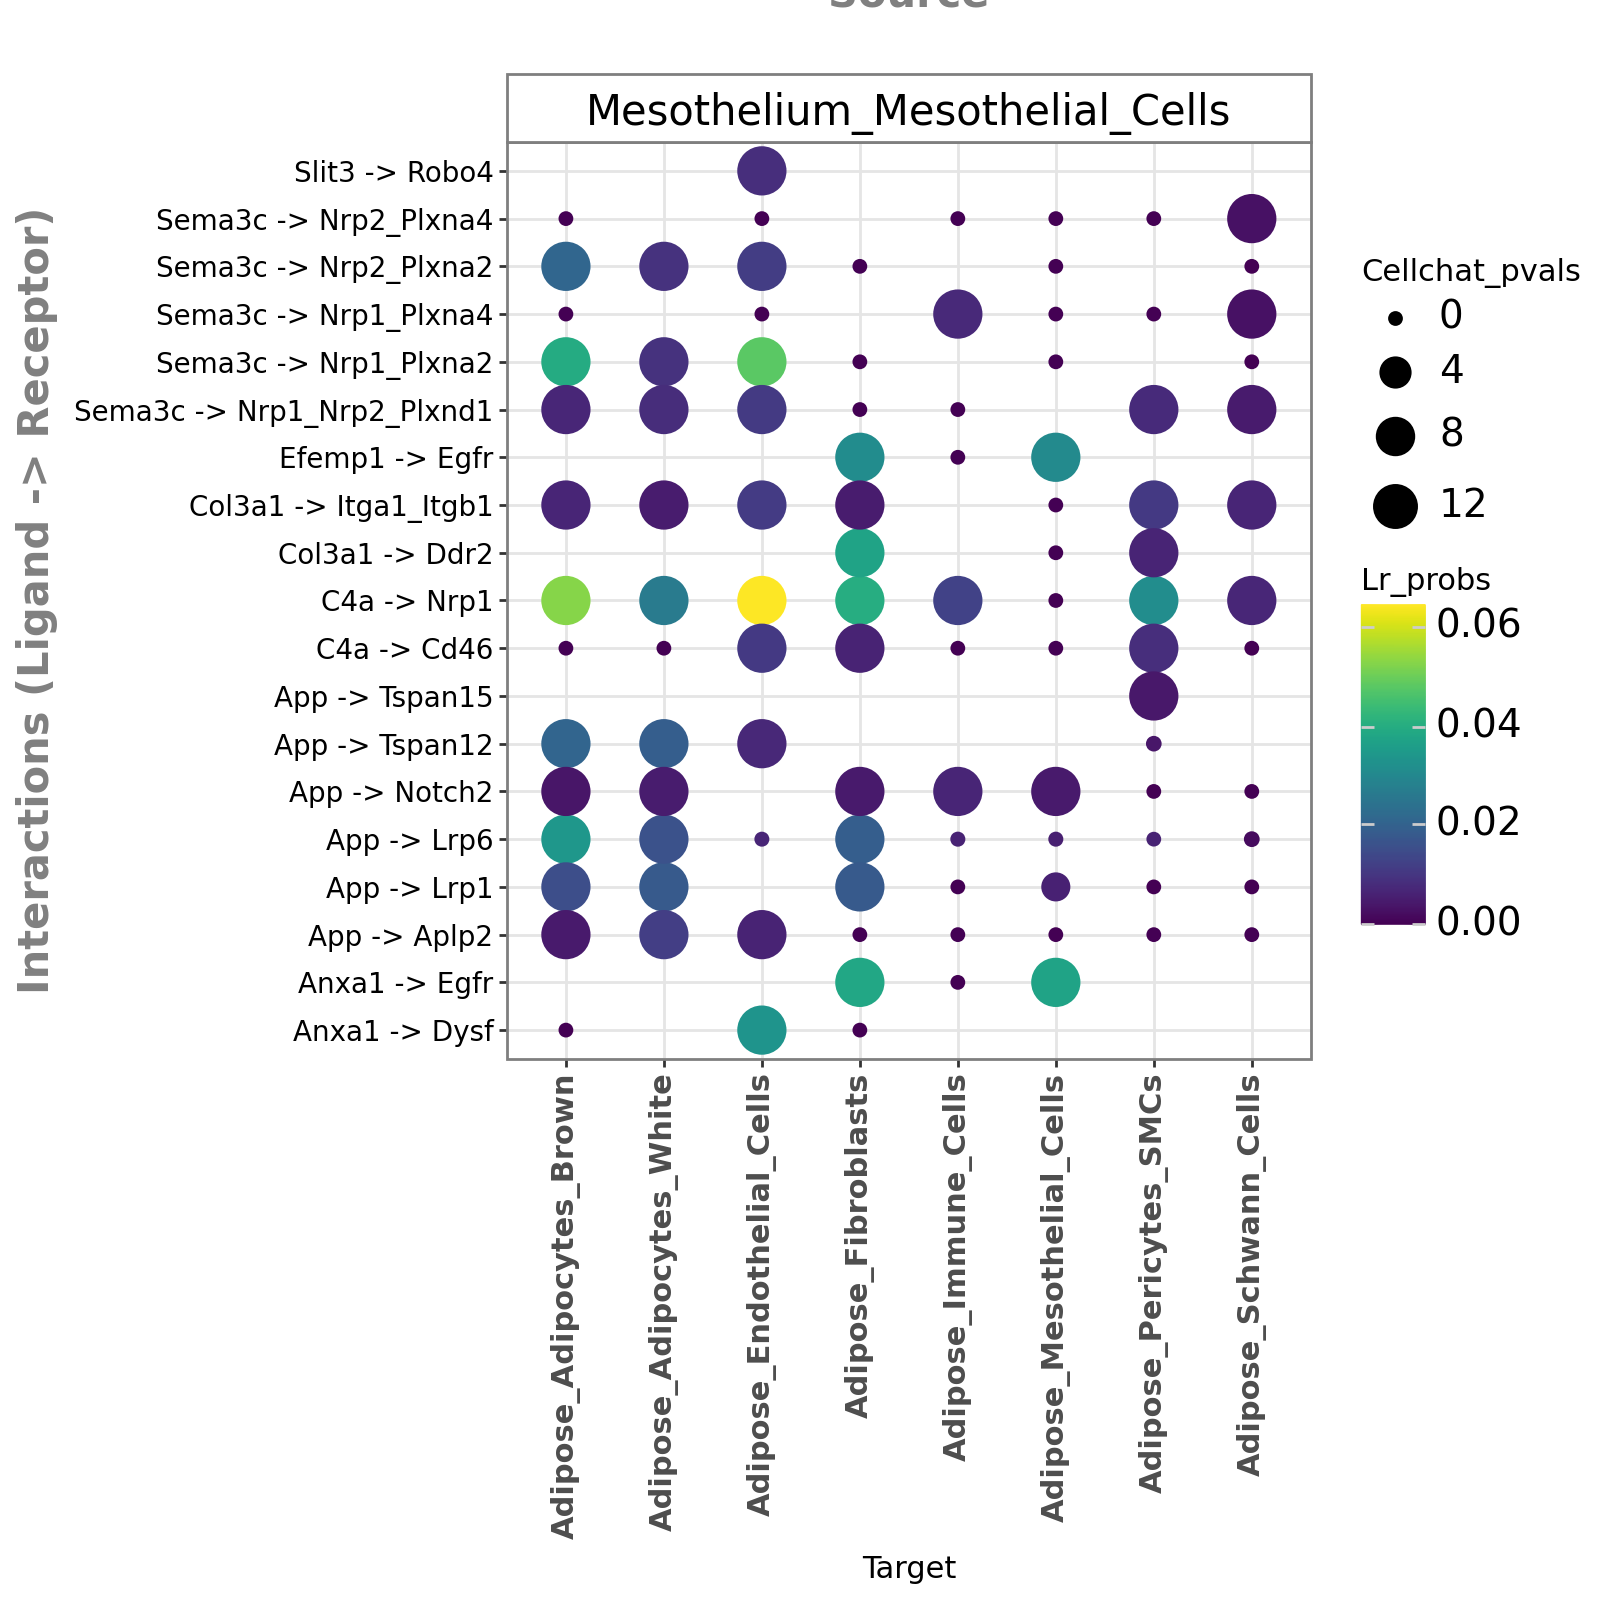

In [62]:
li.pl.dotplot(adata = adata, 
              colour='lr_probs',
              size='cellchat_pvals',
              inverse_size=True, # we inverse sign since we want small p-values to have large sizes
              source_labels='Mesothelium_Mesothelial_Cells',
              target_labels=list(adata[adata.obs.tissue_type == 'Adipose'].obs['tissue_celltype_broad'].unique()),
              figure_size=(8, 8),
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              filter_fun=lambda x: x['cellchat_pvals'] <= 0.05,
              uns_key='mcdb_res' # uns_key to use, default is 'liana_res' 
             )

<div class="alert alert-info">
   
**Note**
    
Missing dots here would represent interactions for which the ligand and receptor are not expressed above the `expr_prop`. One can change this threshold by setting `expr_prop` to a different value. Alternatively, setting `return_all_lrs` to `True` will return all ligand-receptor interactions, regardless of expression.
</div>

### Tileplot

While dotplots are useful to visualize the most relevant interactions, LIANA's tileplots are more useful when visualizing the statistics of ligands and receptors, individually.

In [40]:
# my_plot = li.pl.tileplot(adata = adata, 
#                          # NOTE: fill & label need to exist for both
#                          # ligand_ and receptor_ columns
#                          fill='lr_probs',
#                          label='props',
#                          label_fun=lambda x: f'{x:.2f}',
#                          top_n=10, 
#                          orderby='cellchat_pvals',
#                          orderby_ascending=True,
#                          source_labels=adata.uns['ccdb_res'].source.unique(),
#                          target_labels=adata.uns['ccdb_res'].target.unique(),
#                          uns_key='ccdb_res', # NOTE: default is 'liana_res'
#                          source_title='Ligand',
#                          target_title='Receptor',
#                          figure_size=(16, 7)
#                          )
# my_plot

### Rank Aggregate
In addition to the individual methods, LIANA also provides a consensus that integrates the predictions of individual methods.
This is done by ranking and aggregating ([RRA](https://academic.oup.com/bioinformatics/article-abstract/28/4/573/213339)) the ligand-receptor interaction predictions from all methods.

In [63]:
# Run rank_aggregate on cellchatdb
li.mt.rank_aggregate(adata, 
                     groupby='tissue_celltype_broad',
                     resource=resource_mouse,
                     expr_prop=0.1,
                     verbose=True,
                     key_added='ccdb_rra_res' # uns_key to use, default is 'liana_res'
)   

Using `.raw`!


/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Converting `tissue_celltype_broad` to categorical!
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
['Cyp2c6_v1-ps2', 'Metazoa_SRP-12', 'Metazoa_SRP-13', 'Metazoa_SRP-16', 'Metazoa_SRP-17', 'Metazoa_SRP-22', 'Metazoa_SRP-24', 'RNaseP_nuc-23', 'RNase_MRP', 'Y_RNA-10', 'Y_RNA-5'] contain `_`. Consider replacing those!


Using provided `resource`.


0.13 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 21933 samples and 656 features


/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:06<00:00, 154.07it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [12]:
# Run rank_aggregate on mouseconsensus
li.mt.rank_aggregate(adata, 
                     groupby='tissue_celltype_broad',
                     resource_name='mouseconsensus',
                     expr_prop=0.1,
                     verbose=True,
                     key_added='mcdb_rra_res' # uns_key to use, default is 'liana_res'
) 

Using resource `mouseconsensus`.
Using `.raw`!
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
Converting `tissue_celltype_broad` to categorical!
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
['Cyp2c6_v1-ps2', 'Metazoa_SRP-12', 'Metazoa_SRP-13', 'Metazoa_SRP-16', 'Metazoa_SRP-17', 'Metazoa_SRP-22', 'Metazoa_SRP-24', 'RNaseP_nuc-23', 'RNase_MRP', 'Y_RNA-10', 'Y_RNA-5'] contain `_`. Consider replacing those!
0.13 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 21933 samples and 1346 features


/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:296: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|██████████| 1000/1000 [00:09<00:00, 106.99it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [134]:
adata.uns['ccdb_rra_res'][(adata.uns['ccdb_rra_res']['specificity_rank'] <= 0.05) & (adata.uns['ccdb_rra_res']['source'] == 'Mesothelium_Mesothelial_Cells')]

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
4802,Mesothelium_Mesothelial_Cells,Adipose_Endothelial_Cells,Sema3c,Nrp1_Plxna2,1.692772,0.0,2.744856,0.954413,2.145568,0.046292,0.947412,0.027946,0.004590
4748,Mesothelium_Mesothelial_Cells,Adipose_Adipocytes_Brown,Sema3c,Nrp1_Plxna2,1.524498,0.0,2.292042,0.813436,1.755235,0.038655,0.942736,0.039337,0.022470
4750,Mesothelium_Mesothelial_Cells,Adipose_Adipocytes_Brown,Sema3c,Nrp2_Plxna2,1.165280,0.0,1.325410,0.685293,1.469777,0.022653,0.926030,0.039337,0.123494
4806,Mesothelium_Mesothelial_Cells,Adipose_Endothelial_Cells,Sema3c,Plxnd1,1.151038,0.0,1.287087,0.819379,1.948163,0.031854,0.925019,0.039337,0.132131
4804,Mesothelium_Mesothelial_Cells,Adipose_Endothelial_Cells,Sema3c,Nrp2_Plxna2,1.137715,0.0,1.251234,0.657094,1.804512,0.021385,0.924033,0.039337,0.140090
4801,Mesothelium_Mesothelial_Cells,Adipose_Endothelial_Cells,Sema3c,Nrp1_Nrp2_Plxnd1,1.137715,0.0,1.251234,0.657094,1.804512,0.021385,0.924033,0.039337,0.140090
4774,Mesothelium_Mesothelial_Cells,Adipose_Adipocytes_White,Sema3c,Plxnd1,1.016083,0.0,0.923930,0.651547,1.542096,0.022866,0.912682,0.039337,0.260364
4771,Mesothelium_Mesothelial_Cells,Adipose_Adipocytes_White,Sema3c,Nrp1_Nrp2_Plxnd1,1.016083,0.0,0.923930,0.651547,1.542096,0.022866,0.912682,0.039337,0.260364
4747,Mesothelium_Mesothelial_Cells,Adipose_Adipocytes_Brown,Sema3c,Nrp1_Nrp2_Plxnd1,1.001832,0.0,0.885583,0.633825,1.472832,0.021917,0.910978,0.039337,0.288946
4752,Mesothelium_Mesothelial_Cells,Adipose_Adipocytes_Brown,Sema3c,Plxnd1,1.001832,0.0,0.885583,0.633825,1.472832,0.021917,0.910978,0.039337,0.288946


In [13]:
adata.uns['mcdb_rra_res']

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
10902,Adipose_Schwann_Cells,Adipose_Pericytes_SMCs,Ncam1,Cacna1c,2.966313,0.000,8.464007,4.267382,3.560400,0.243129,0.969359,4.030771e-07,3.506269e-08
349,Adipose_Adipocytes_Brown,Adipose_Endothelial_Cells,Vegfa,Nrp1,2.718014,0.000,7.384279,1.073884,2.091684,0.054299,0.967266,6.100166e-03,1.402449e-07
6839,Adipose_Mesothelial_Cells,Adipose_Endothelial_Cells,C4a,Nrp1,2.641592,0.000,6.977655,1.423418,1.835483,0.056796,0.966358,4.846635e-03,3.155379e-07
110,Adipose_Adipocytes_Brown,Adipose_Adipocytes_Brown,Vegfa,Nrp1,2.505712,0.000,6.205726,0.925731,1.492343,0.045633,0.964399,1.523277e-02,1.261994e-06
6959,Adipose_Mesothelial_Cells,Adipose_Endothelial_Cells,Sema3c,Nrp1_Plxna2,2.502383,0.000,6.048193,1.730843,2.074818,0.102002,0.963955,1.784749e-04,1.717643e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
24,Adipose_Adipocytes_Brown,Adipose_Adipocytes_Brown,App,Rpsa,0.488965,1.000,0.149365,-0.005618,-0.838599,0.003739,0.807789,1.000000e+00,1.000000e+00
22,Adipose_Adipocytes_Brown,Adipose_Adipocytes_Brown,App,Ncstn,0.468701,0.305,0.117409,0.078889,-0.525259,0.008327,0.788406,1.000000e+00,1.000000e+00
2,Adipose_Adipocytes_Brown,Adipose_Adipocytes_Brown,Adam10,Notch2,0.387594,0.000,0.133068,0.138273,-0.381209,0.005707,0.798660,1.000000e+00,1.000000e+00
16020,Mesothelium_Unknown,Mesothelium_Pericytes_SMCs,Lama2,Itga1,0.373780,1.000,0.139702,-0.129691,0.101078,0.001266,0.802544,1.000000e+00,1.000000e+00


The remainder of the columns in this dataframe are those coming from each of the methods included in the `rank_aggregate` - i.e. see the `show_methods` to map methods to scores.

In [ ]:
adata.write_h5ad('../data/adata_meso_tapvat_with_liana_results.h5ad')

... storing 'tissue_type' as categorical
... storing 'celltype' as categorical
... storing 'celltype_broad' as categorical
... storing 'tissue_celltype_broad' as categorical
... storing 'tissue_celltype' as categorical


### Dotplot

We will now plot the most 'relevant' interactions ordered to the `magnitude_rank` results from aggregated_rank.

/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


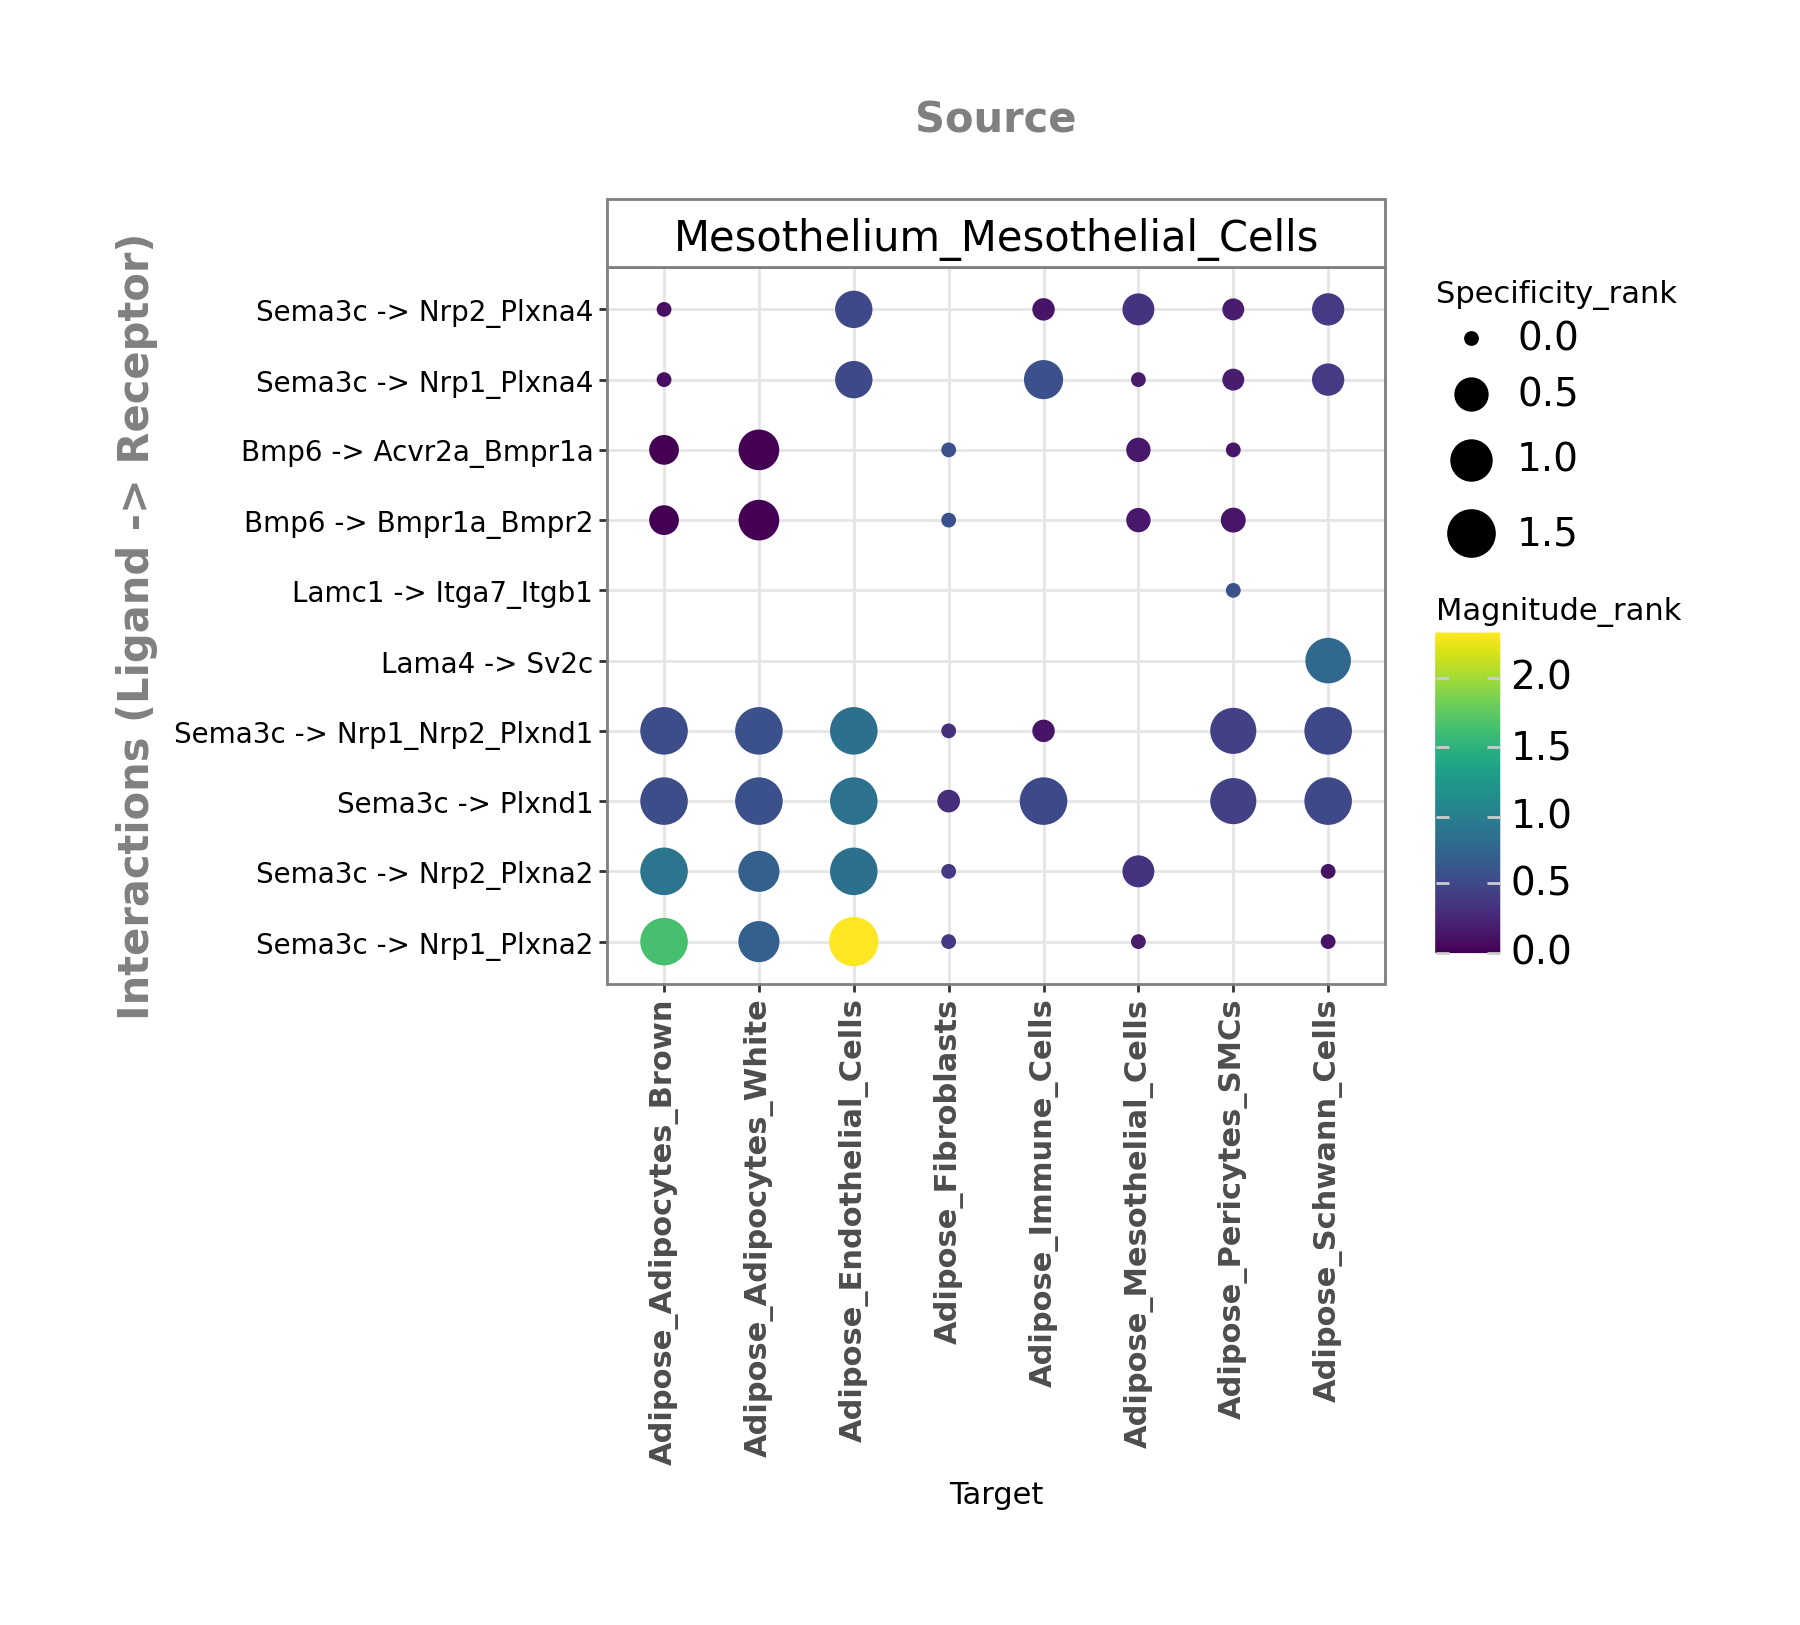

In [102]:
li.pl.dotplot(adata = adata, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
              source_labels='Mesothelium_Mesothelial_Cells',
              target_labels=list(adata[adata.obs.tissue_type == 'Adipose'].obs['tissue_celltype_broad'].unique()),
              top_n=10, 
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(8, 7),
              uns_key='ccdb_rra_res' # uns_key to use, default is 'liana_res'
             )

/mnt/home/terrianl/anaconda3/envs/lianaEnv2/lib/python3.12/site-packages/liana/plotting/_common.py:108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


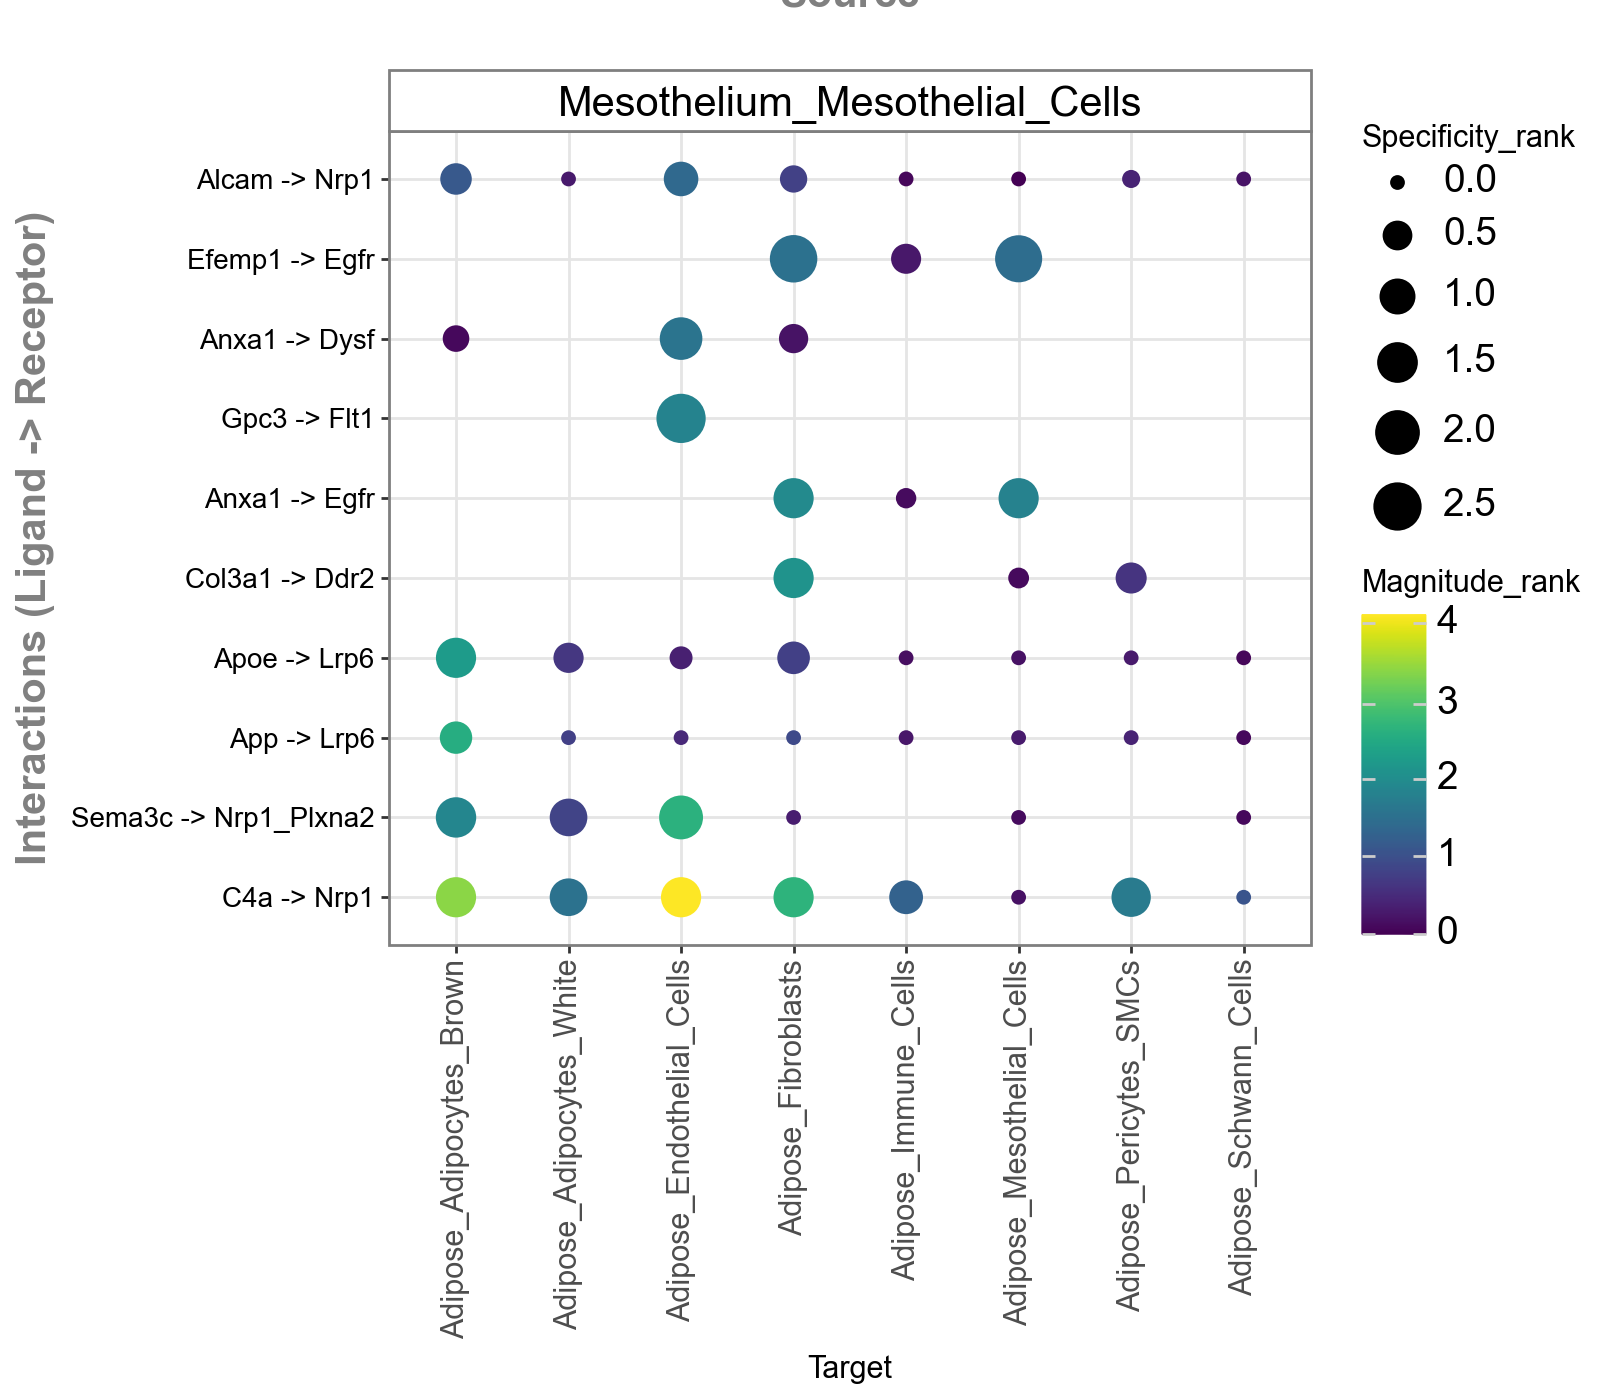

In [15]:
from plotnine import theme, element_text

# LIANA dotplot returns a plotnine ggplot object
p = li.pl.dotplot(adata = adata, 
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
              source_labels='Mesothelium_Mesothelial_Cells',
              target_labels=list(adata[adata.obs.tissue_type == 'Adipose'].obs['tissue_celltype_broad'].unique()),
              top_n=10, 
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(8, 7),
              uns_key='mcdb_rra_res'
             )

# Modify plotnine theme:
# - family='Arial' sets the font
# - weight='normal' removes bold formatting from x-axis tick labels
p = p + theme(
    text=element_text(family='Arial'),
    axis_text_x=element_text(
        family='Arial',
        weight='normal'
    ),
    axis_text_y=element_text(
        family='Arial',
        weight='normal'
    )
)

# Display the modified plot
p

Similarly, we can also treat the ranks provided by RRA as a probability distribution to which we can `filter` interactions
according to how robustly and highly ranked they are across the different methods.

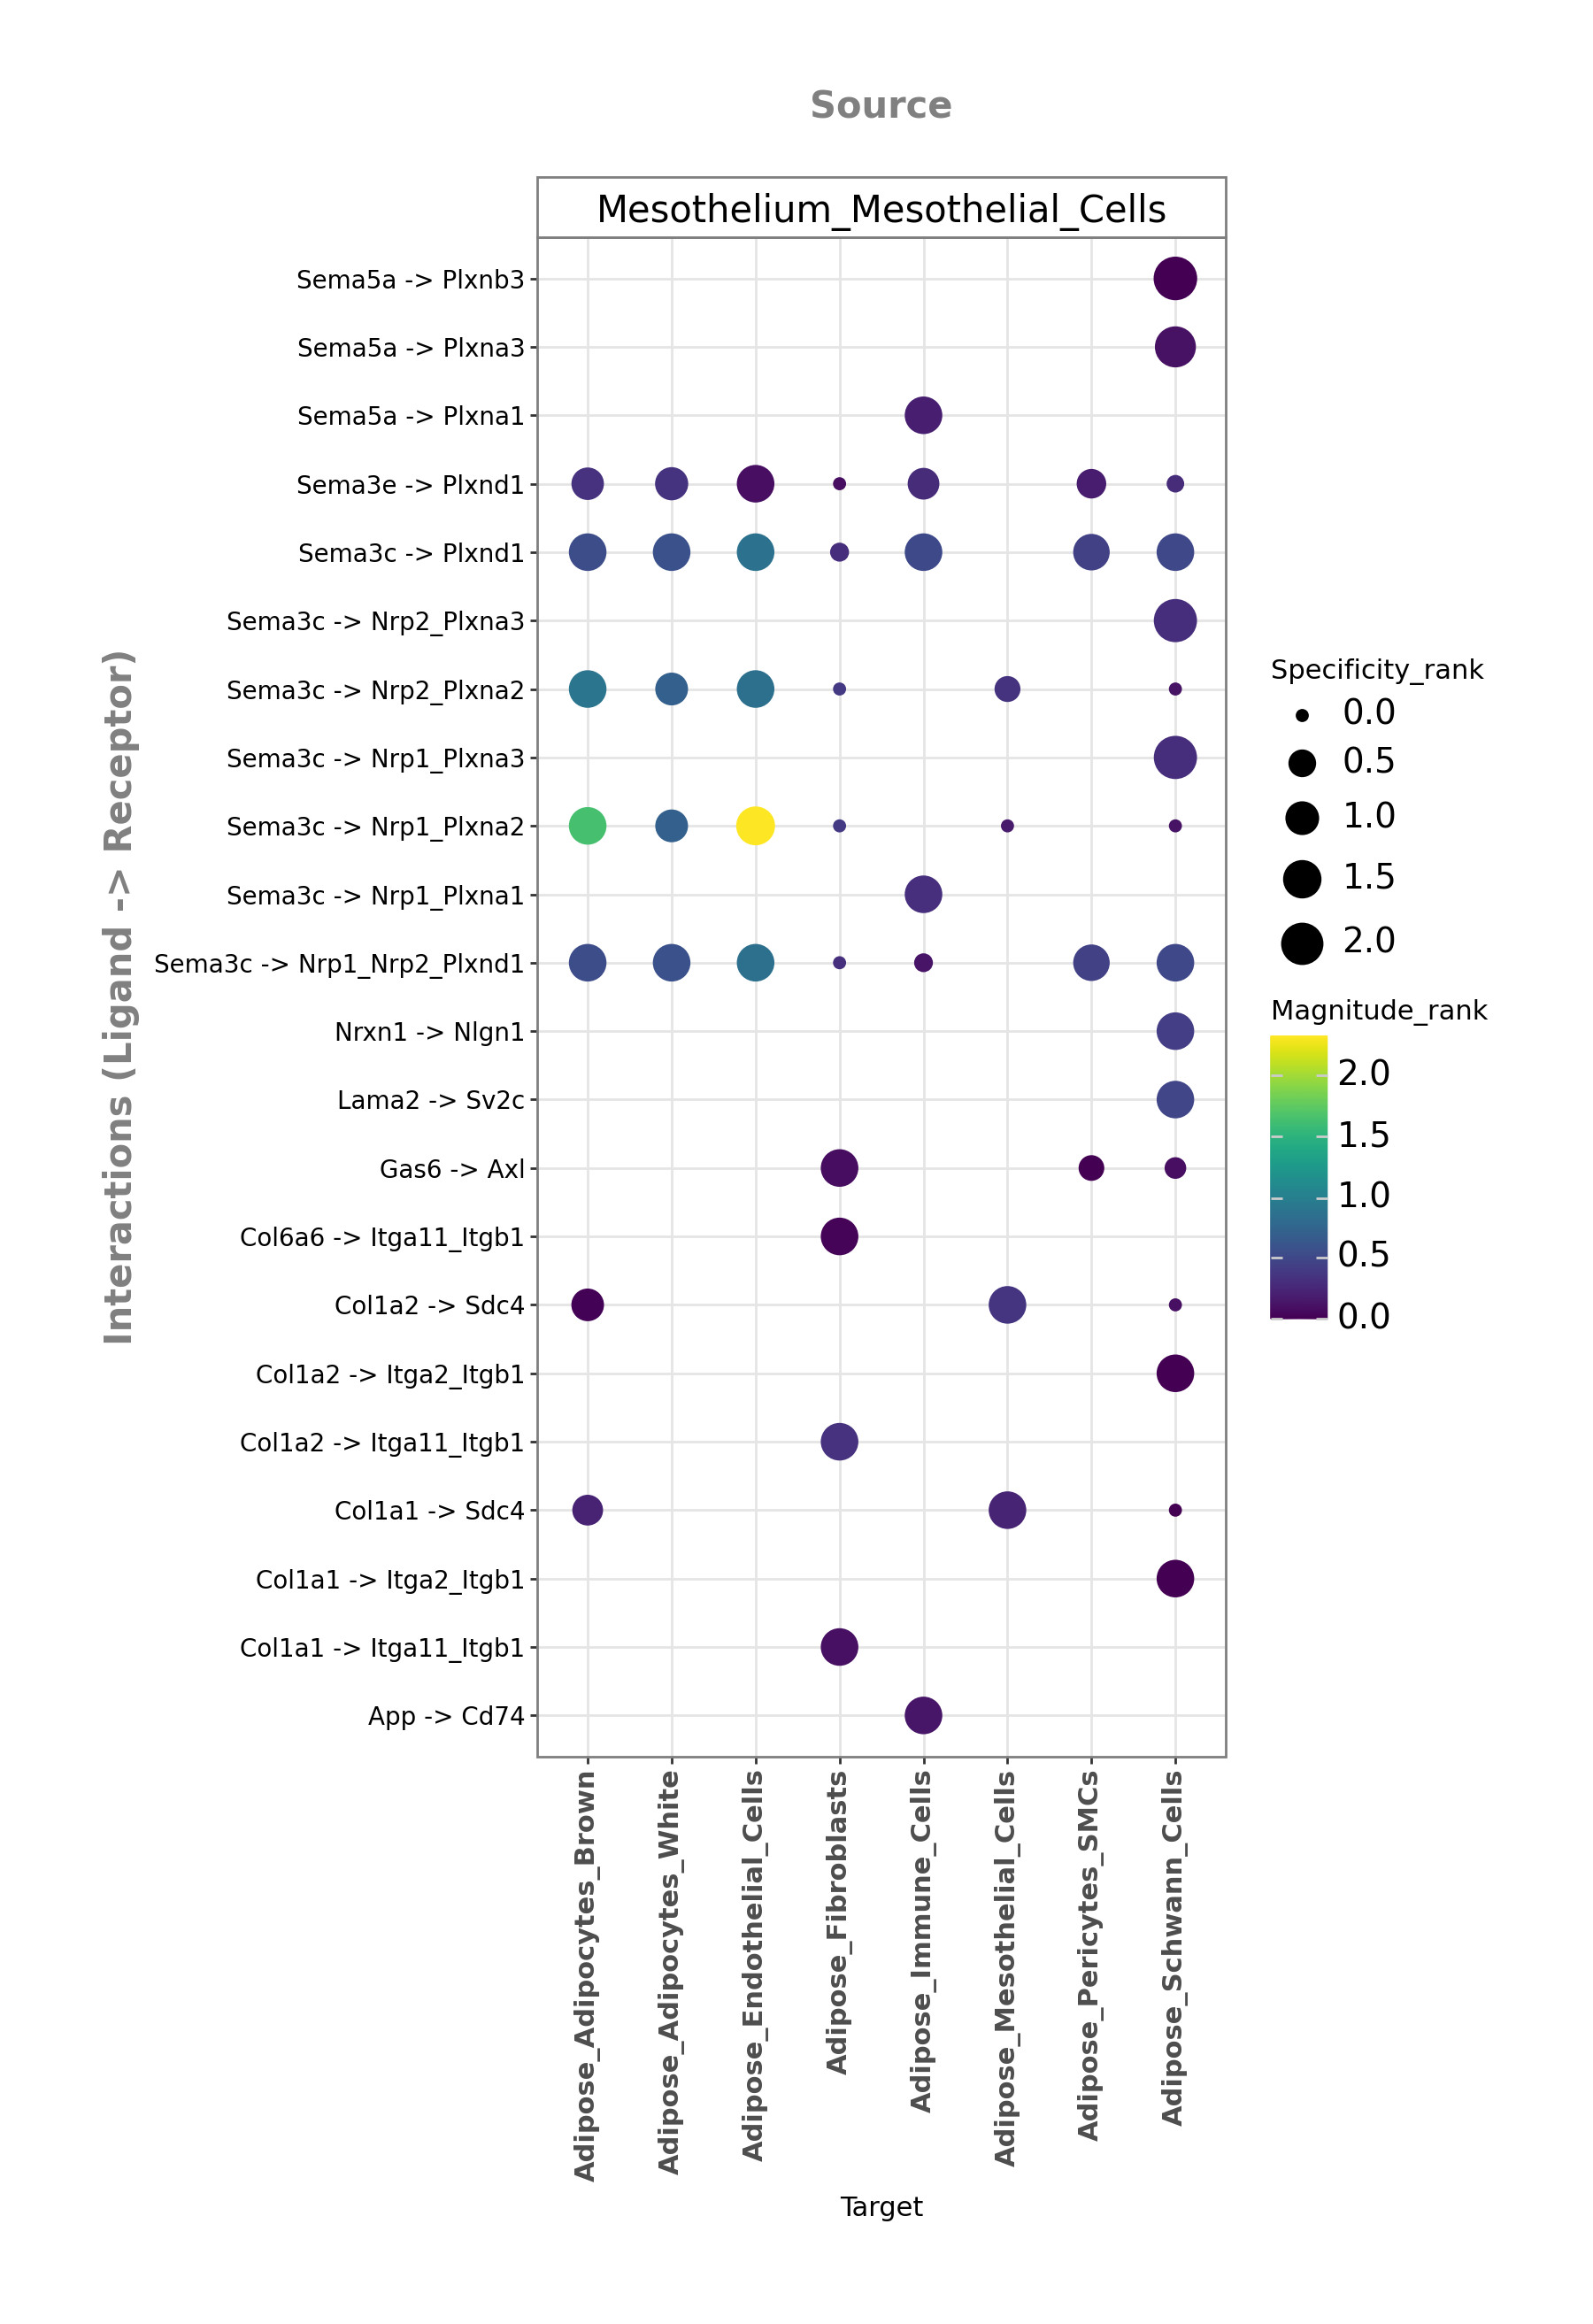

In [131]:
my_plot = li.pl.dotplot(adata = adata, 
                        colour='magnitude_rank',
                        size='specificity_rank',
                        inverse_size=True,
                        inverse_colour=True,
                        source_labels='Mesothelium_Mesothelial_Cells',
                        target_labels=list(adata[adata.obs.tissue_type == 'Adipose'].obs['tissue_celltype_broad'].unique()),
                        filter_fun=lambda x: x['specificity_rank'] <= 0.05,
                        orderby='magnitude_rank',
                        orderby_ascending=True,
                        figure_size=(8, 12),
                        uns_key='ccdb_rra_res' # uns_key to use, default is 'liana_res'
                       )
my_plot

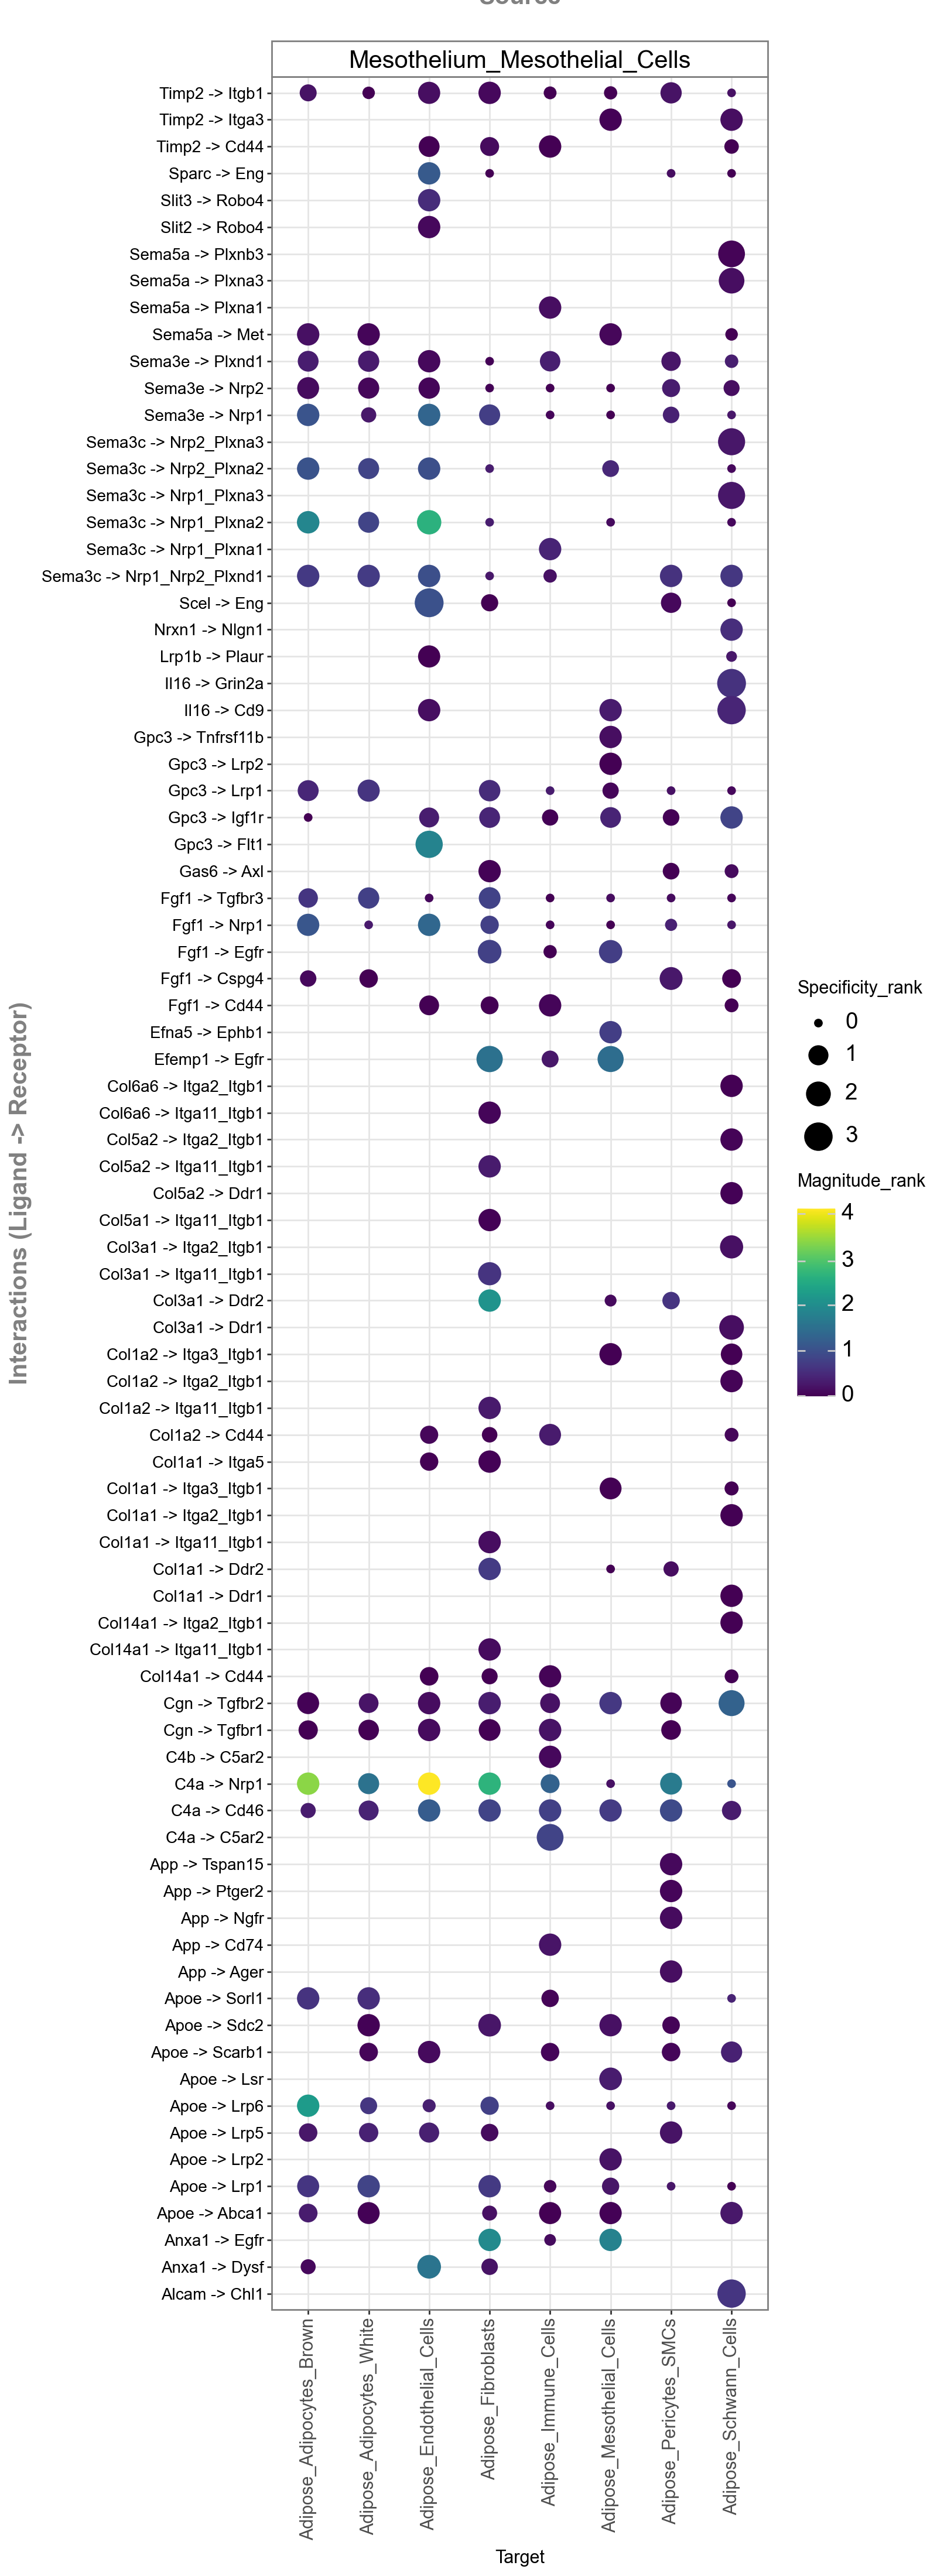

In [21]:
from plotnine import theme, element_text

# LIANA dotplot returns a plotnine ggplot object
p = li.pl.dotplot(adata = adata, 
                        colour='magnitude_rank',
                        size='specificity_rank',
                        inverse_size=True,
                        inverse_colour=True,
                        source_labels='Mesothelium_Mesothelial_Cells',
                        target_labels=list(adata[adata.obs.tissue_type == 'Adipose'].obs['tissue_celltype_broad'].unique()),
                        filter_fun=lambda x: x['specificity_rank'] <= 0.05,
                        orderby='magnitude_rank',
                        orderby_ascending=True,
                        figure_size=(8, 22),
                        uns_key='mcdb_rra_res' 
                       )

# Modify plotnine theme:
# - family='Arial' sets the font
# - weight='normal' removes bold formatting from x-axis tick labels
p = p + theme(
    text=element_text(family='Arial'),
    axis_text_x=element_text(
        family='Arial',
        weight='normal'
    ),
    axis_text_y=element_text(
        family='Arial',
        weight='normal'
    )
)

# Display the modified plot
p

Save the plot to a file:

In [19]:
# my_plot.save('dotplot.pdf')

#### Circle Plot

While the majority of liana's plots are in plotnine, thanks to @WeipengMo, we also provide a circle plot (drawn in networkx):

In [115]:
### Set color palette to remain consistent across plots
import custom_functions_scviEnv as cf
adata.uns["tissue_celltype_broad_colors"] = cf.large_palette

In [116]:
adata.uns["tissue_celltype_broad_colors"]

['lightseagreen',
 'mediumseagreen',
 'darkseagreen',
 'lightcoral',
 'tomato',
 'darkred',
 'lightsteelblue',
 'lightblue',
 'steelblue',
 'peachpuff',
 'goldenrod',
 'darkgoldenrod',
 'lightgreen',
 'green',
 'darkgreen',
 'lightgrey',
 'darkgrey',
 'grey',
 'lavenderblush',
 'pink',
 'hotpink',
 'lightcyan',
 'cyan',
 'darkcyan',
 'thistle',
 'mediumorchid',
 'purple',
 'orange']

In [118]:
li.pl.circle_plot(adata,
                  groupby='tissue_celltype_broad',
                  score_key='magnitude_rank',
                  inverse_score=True,
                  #source_labels='Mesothelium_Mesothelial_Cells',
                  #filter_fun=lambda x: x['specificity_rank'] <= 0.01,
                  pivot_mode='counts', # NOTE: this will simply count the interactions, 'mean' is also available
                  figure_size=(8, 8),
                  uns_key='mcdb_rra_res',
                  node_label_size=11
                  )

<Axes: >

In [111]:
li.pl.circle_plot(adata,
                  groupby='tissue_celltype_broad',
                  score_key='magnitude_rank',
                  inverse_score=True,
                  # source_labels='Adipocytes_Brown',
                  #filter_fun=lambda x: x['specificity_rank'] <= 0.05,
                  pivot_mode='mean', # NOTE: this will simply count the interactions, 'mean' is also available
                  figure_size=(8, 8),
                  uns_key='mcdb_rra_res',
                  node_label_size=11
                  )

<Axes: >

#### Chord diagram

In [113]:
import pandas as pd

df = adata.uns["ccdb_rra_res"]

# aggregate interaction strength
agg = (
    df.groupby(["source", "target"])["magnitude_rank"]
    .mean()
    .reset_index()
)

# pivot into matrix
matrix_df = pd.DataFrame(agg.pivot(index="source", columns="target", values="magnitude_rank").fillna(0))
matrix_df

target,Adipose_Adipocytes_Brown,Adipose_Adipocytes_White,Adipose_Endothelial_Cells,Adipose_Fibroblasts,Adipose_Immune_Cells,Adipose_Mesothelial_Cells,Adipose_Pericytes_SMCs,Adipose_Schwann_Cells,Mesothelium_Adipocytes_Brown,Mesothelium_Adipocytes_White,Mesothelium_Endothelial_Cells,Mesothelium_Fibroblasts,Mesothelium_Immune_Cells,Mesothelium_Mesothelial_Cells,Mesothelium_Pericytes_SMCs,Mesothelium_Schwann_Cells
source,,,,,,,,,,,,,,,,
Adipose_Adipocytes_Brown,0.442959,0.464414,0.391685,0.547703,0.497628,0.449730,0.462069,0.458661,0.473054,0.528661,0.426523,0.480079,0.421236,0.421824,0.416609,0.642427
Adipose_Adipocytes_White,0.499656,0.611694,0.519121,0.513352,0.611567,0.585689,0.500644,0.551024,0.549305,0.560256,0.600776,0.630847,0.793730,0.592377,0.600210,0.615040
Adipose_Endothelial_Cells,0.506077,0.548758,0.578879,0.652904,0.642811,0.633319,0.405310,0.621177,0.702022,1.000000,0.754314,0.620697,0.634790,0.447592,0.643134,0.000000
Adipose_Fibroblasts,0.438169,0.535274,0.453663,0.528024,0.555522,0.472705,0.448852,0.483140,0.530752,0.765606,0.524029,0.723795,0.847908,0.329206,0.514768,0.000000
Adipose_Immune_Cells,0.710866,0.669457,0.602659,0.689807,0.777458,0.713631,0.608864,0.698232,0.950321,0.000000,0.672884,0.867120,0.675968,0.477972,0.870880,0.000000
Adipose_Mesothelial_Cells,0.545872,0.666932,0.607962,0.686445,0.697285,0.677958,0.533514,0.645424,0.774096,0.906729,0.726109,0.792550,0.844831,0.685129,0.728314,0.000000
Adipose_Pericytes_SMCs,0.510091,0.563943,0.536047,0.621609,0.531091,0.599808,0.570960,0.536231,0.536314,0.483545,0.564106,0.752596,0.868876,0.669217,0.540213,0.000000
Adipose_Schwann_Cells,0.450673,0.539463,0.461422,0.599346,0.625015,0.585438,0.459022,0.544672,0.582856,0.444068,0.664143,0.606869,0.689600,0.747640,0.644515,0.273666
Mesothelium_Adipocytes_Brown,0.547293,0.516405,0.588507,0.685361,0.713022,0.686161,0.447514,0.642778,0.669848,0.833183,0.732376,0.582330,0.000000,0.000000,0.657381,0.000000


In [114]:
from pycirclize import Circos

circos = Circos.chord_diagram(
    matrix_df,
    space = 5,
    cmap = "tab10",
    label_kws=dict(size=12),
    link_kws=dict(ec="black", lw=0.5, direction=1)
)

fig = circos.plotfig()
fig.show()

In [94]:
fig.show()

## Customizing LIANA's rank aggregate

LIANA's rank aggregate is also customizable, and the user can choose to include only a subset of the methods.

For example, let's generate a consensus with geometric mean and logfc methods only:

In [23]:
methods = [logfc, geometric_mean]
new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)

In [24]:
new_rank_aggregate(adata,
                   groupby='bulk_labels',
                   expr_prop=0.1, 
                   verbose=True,
                   # Note that with this option, we don't perform permutations
                   # and hence we exclude the p-value for geometric_mean, as well as specificity_rank
                   n_perms=None,
                   use_raw=True,
                   )

Using resource `consensus`.
Using `.raw`!
/Users/b260-admin/miniforge3/envs/liana311/lib/python3.11/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/b260-admin/miniforge3/envs/liana311/lib/python3.11/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.94 of entities in the resource are missing from the data.
/Users/b260-admin/miniforge3/envs/liana311/lib/python3.11/site-packages/liana/method/sc/_liana_pipe.py:280: ImplicitModificationWarning: Setting element `.layers['normcounts']` of view, initializing view as actual.


Generating ligand-receptor stats for 700 samples and 43 features
Assuming that counts were `natural` log-normalized!
Running log2FC
Running Geometric Mean


Check the results

In [25]:
adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_logfc,lr_gmeans,magnitude_rank
110,CD14+ Monocyte,CD56+ NK,TIMP1,CD63,1.435273,2.126363,0.000776
109,CD14+ Monocyte,CD56+ NK,S100A9,ITGB2,1.069681,2.048953,0.001553
20,CD14+ Monocyte,CD14+ Monocyte,S100A9,ITGB2,1.069747,1.979753,0.002329
838,CD56+ NK,CD56+ NK,SPON2,ITGB2,1.860055,1.926317,0.003106
782,CD56+ NK,CD14+ Monocyte,SPON2,ITGB2,1.860121,1.861258,0.003882


## Method Details
(Rendered version of **Supplementary Table 3** from the manuscript)

| Method                         | Magnitude                                                                                      | Specificity                                                                                  |
|--------------------------------|------------------------------------------------------------------------------------------------|----------------------------------------------------------------------------------------------|
| [CellPhoneDBv2](https://www.nature.com/articles/s41596-020-0292-x)                  | $$LRmean_{k,ij} = \frac{L_{C_{i}} + R_{C_{j}}}{2}$$                                             | See ρ                                                                                        |
| Geometric Mean                 | $$LRgeometric.mean_{k,ij} = \sqrt{L_{C_{i}} \cdot R_{C_{j}}}$$                                 | See ρ                                                                                        |
| [CellChat's](https://www.nature.com/articles/s41467-021-21246-9) LR probabilities †      | $$LRprob_{k,ij} = \frac{L^*_{C_{i}} \cdot R^*_{C_{j}}}{Kh + L^*_{C_{i}} \cdot R^*_{C_{j}}}$$ where Kh is a normalizing parameter (set to 0.5 by default) and L* & R* are aggregated using Tuckey's Trimean function (See below). | See ρ                                                                                        |
| [SingleCellSignalR](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7261168/)              | $$LRscore_{k,ij} = \frac{\sqrt{L_{C_{i}} R_{C_{j}}}}{\sqrt{L_{C_{i}} R_{C_{j}}} + \mu}$$ where $\mu$ is the mean of the expression matrix M     | -                                                                                            |
| [NATMI](https://www.nature.com/articles/s41467-020-18873-z)                          | $$LRproduct_{k,ij} = L_{C_{i}} R_{C_{j}}$$                                                    | $$SpecificityWeight_{k,ij} = \frac{L_{C_{i}}}{\sum^{n} L_{C_{i}}} \cdot \frac{R_{C_{j}}}{\sum^{n} R_{C_{j}}}$$ |
| [Connectome](https://www.nature.com/articles/s41598-022-07959-x)                     | $$LRproduct_{k,ij} = L_{C_{i}} R_{C_{j}}$$                                                    | $$LRz.mean_{k,ij} = \frac{z_{L_{C_{i}}} + z_{R_{C_{j}}}}{2}$$   where z is the z-score of the expression matrix M|                                             |
| LogFC‡                         | -                                                                                              | $$LRlog2FC_{k,ij} = \frac{\text{Log2FC}_{C_i,L} + \text{Log2FC}_{C_j,R}}{2}$$                |
| [ScSeqComm](https://academic.oup.com/bioinformatics/article/38/7/1920/6511439) (intercellular scores only)   | $$LRinterscore_{k,ij} = \text{min}(P(L_{Ci}), P(R_{Cj}))$$ $$P(X) = \Phi\left(\frac{X - \mu}{\sigma / \sqrt{n}}\right)$$                              Where $\Phi$ is the CDF of a normal distribution, μ is the mean, σ is the standard deviation, and n is the number of observations | -                                                                                            |
| LIANA’s Consensus#             | Used flexibly to combine the Magnitude scores of the methods above. By default, uses all except the Geometric mean and CellChat, independently for magnitude and specificity scores. | Same as Magnitude Rank Aggregate but aggregates the specificity scores of different methods.                                                                                          |

**Shared Notation:**

- k is the k-th ligand-receptor interaction
- L - expression of ligand L; R - expression of receptor R; See Ѫ
- C - cell cluster
- i - cell group i
- j - cell group j
- M - a library-size normalised and log1p-transformed gene expression matrix
- X - normalised gene expression vector

**Permutations to calculate specificity (ρ):**

$$ p\text{-value}_{k,ij} = \frac{1}{P} \sum_{p=1}^{P} [fun_{permuted}(L^*_{C_{i}}, R^*_{C_{j}}) \geq fun_{observed}(L^*_{C_{i}}, R^*_{C_{j}})]$$

where P is the number of permutations, and L* and R* are ligand and receptor expressions aggregated by group (cluster) using fun; arithmetic mean for CellPhoneDB and Geometric Mean, and Tuckey’s TriMean for CellChat:

$$TriMean(X) = \frac{Q_{0.25}(X) + 2 \cdot Q_{0.5}(X) + Q_{0.75}(X)}{4}$$

**Consensus(#)**

First, a normalised rank matrix [0,1] is generated separately for magnitude and specificity as: 

$$r_{ij} = \frac{rank_{ij}}{\max(rank_i)} \quad (1 \leq i \leq m, 1 \leq j \leq n)$$

where m is the number of ranked score vectors, n is the length of each score vector (number of interactions), rankij is the rank of the j-th element (interaction) in the i-th score rank vector, and max(ranki) is the maximum rank in the i-th rank vector.

For each normalised rank vector r, we then ask how probable it is to obtain rnull(k)<= r(k), where rnull(k) is a rank vector generated under the null hypothesis. The [RobustRankAggregate](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3278763/) method expresses the probability rnull(k)<= r(k) as k,n(r) through a beta distribution. This entails that we obtain probabilities for each score vector r as:

$$p(r) = \underset{1, ..., n}{min} \beta_k,_n(r) * n$$

where we take the minimum probability for each interaction across the score vectors, and we apply a Bonferroni multi-testing correction to the P-values by multiplying them by n.


**Notes:**

- Δ Some differences are expected with the original implementations largely due to different preprocessing steps which LIANA+ harmonised across the different methods. Specifically, LIANA+ considers the minimum score (e.g. average expression) for complex subunits, while some methods consider the mean, geometric mean, or simply do not account for complexes at all.
- † The original [CellChat](https://github.com/jinworks/CellChat) implementation additionally uses information about mediator proteins and pathways, which are specific to the CellChat resource. Since we wish to keep LIANA+ resource-agnostic, **we do not utilise mediator information**, as such while the remainder of the score calculation is identical to CellChat's LR probabilities, some differences are anticipated.
- Ѫ While we refer to the genes as ligands and receptors for simplicity, these can represent the gene expression also of membrane-bound or extracellular-matrix proteins, as well as heteromeric complexes for which the minimum expression across subunits is used.
- ‡ 1-vs-rest cell group log2FC for each gene is calculated as $$log2FC = \log_2\left(\text{mean}(X_i)\right) - \log_2\left(\text{mean}(X_{\text{not}_i})\right)$$
- (*) LIANA considers interactions as occurring only if both the ligand and receptor, as well as all of their subunits, are expressed above a certain proportion of cells in both clusters involved in the interaction (0.1 by default). This can be formulated as an indicator function as follows:
$$I \left\{ L_{C_j}^{expr.prop} \geq 0.1 \text{ and } R_{C_j}^{expr.prop} \geq 0.1 \right\}$$



### 🙏 <span style="color: darkred;"> Please consider citing the original methods when using their LIANA+ adaptations in your work! 🙏 </span>

*While LIANA+ simply aims to ease ligand-receptor inference, the original authors and developers should be credited for their work.*

*We acknowledge their valuable contributions and we hope you would too!*